In [ ]:
# NOTE: This notebook is used purely for deconvolution analysis.
# However, for model training purposes, it is recommended to utilize the script `train_models.py` for enhanced efficiency.

In [1]:
import numpy as np
import pandas as pd
import pickle as pkl
import os
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from typing import List, Tuple, Union, Optional

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from  torch.utils.data import DataLoader, TensorDataset
import tqdm as tqdm

In [2]:
with open("data_processed/aggregated_malignant_df.pkl", "rb") as file:
   aggregated_malignant_df =  pkl.load(file)

gene_names = ['APOA1', 'DCN', 'DPP4', 'ENG', 'IGFBP5', 'IGFBP6', 'IL1B', 'IL1RN', 'KRT23', 'LDLR', 'MGP', 'MYH11', 'PIGR', 'PTGS1', 'RAMP1', 'RGS5', 'S100A4', 'SPP1', 'TPM2', 'UBE2C']
 
aggregated_malignant_df.head()

expression_data = aggregated_malignant_df[gene_names].values
expression_data_norm = expression_data / aggregated_malignant_df["No_cells"].to_numpy()[:, None]
expression_tensor = torch.tensor(expression_data_norm, dtype=torch.float32)

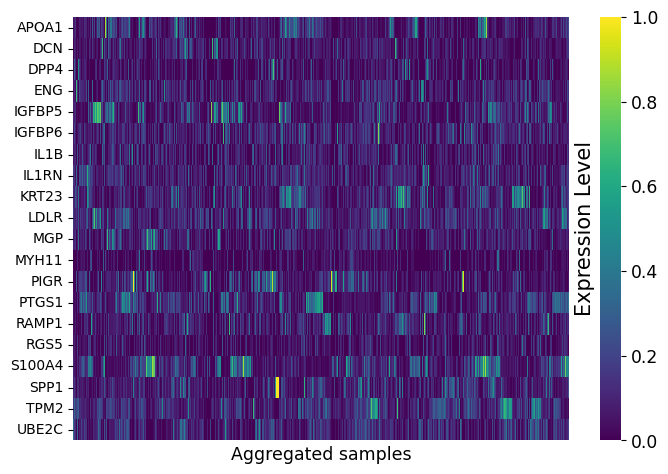

In [3]:
plt.figure(figsize=(8, 5.5))
ax = sns.heatmap(expression_data_norm.T, cmap='viridis', yticklabels=gene_names, xticklabels=False, cbar_kws={'label': 'Expression Level'})
cbar = ax.collections[0].colorbar
cbar.set_label('Expression Level', size=15, labelpad = -60)
cbar.ax.tick_params(labelsize=12.4) 
cbar.ax.set_yticks(np.arange(0, 1.01, 0.2))
plt.xlabel('Aggregated samples', fontsize=12.5)
plt.show()

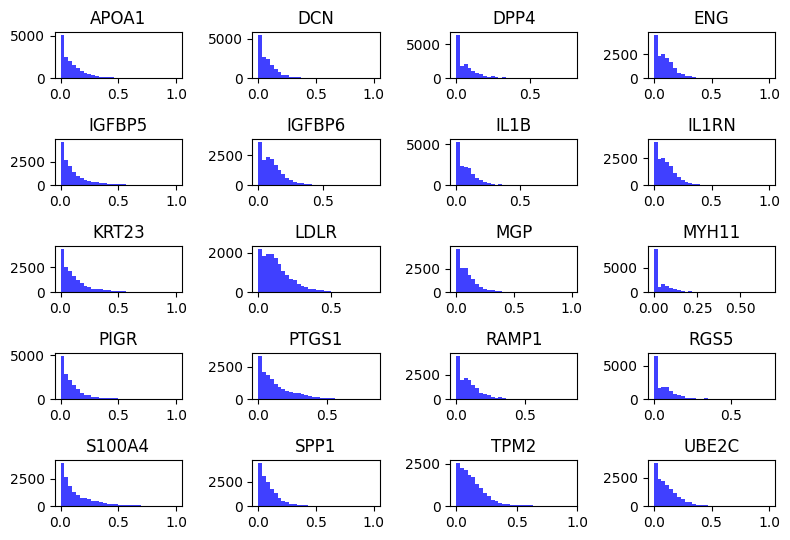

In [4]:
plt.figure(figsize=(8, 5.5))
for i, gene in enumerate(gene_names):
    plt.subplot(5, 4, i + 1)
    plt.hist(expression_data_norm[:, i], bins=30, alpha=0.75, label=gene, color= "blue")
    plt.title(f"{gene}")
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Gene Signature Matrix')

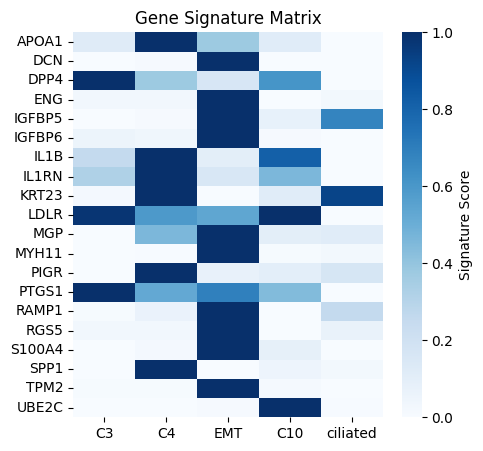

In [5]:
# Load the signature matrix

with open("data_processed/gene_signature_matrix_20.pkl", "rb") as file:
    gene_signature = pkl.load(file)
signature_matrix = gene_signature.to_numpy()[:, 1:].astype(np.float64)
signature_tensor = torch.tensor(signature_matrix, dtype=torch.float32)

# plot the signature matrix
plt.figure(figsize = (5, 5))
sns.heatmap(gene_signature[["C3", "C4", "EMT", "C10", "ciliated"]],
            yticklabels = gene_signature["Genes"].values,
            cmap='Blues', cbar_kws={'label': 'Signature Score'})
plt.title("Gene Signature Matrix")

In [ ]:
# save the expression tensor and the signature tensor as separate .pt files
# save the gene names as a text file

# torch.save(expression_tensor, "data_processed/expression_tensor.pt")
# torch.save(signature_tensor, "data_processed/signature_tensor.pt")
# with open("data_processed/gene_names.txt", "w") as f:
#     f.writelines("\n".join(gene_names))

In [8]:
# NOTE: This code block was purely used for experimentation/development purposes.
# It may not reflect the final model training and evaluation pipeline.
# Please skip to the wandb run instead.

from models.Sig_ZIB_VAE import Sig_ZIB_VAE, train_zib_model
from utils.processing_utils import pytorch_pearson_corr
from sklearn.model_selection import train_test_split

# Generating cell labels using Pearson correlation
correlation = pytorch_pearson_corr(expression_tensor, signature_tensor)
correlation_probs = F.softmax(correlation, dim = 1)

cell_labels = torch.argmax(correlation_probs, dim = 1)

full_dataset = TensorDataset(expression_tensor, cell_labels)
full_dataloader = DataLoader(full_dataset, batch_size = 256, shuffle = True, drop_last = True)

# Additionally, we can also create train and validation dataloaders. 
# Statified split to maintaing class distribution
X_train, X_val, y_train, y_val = train_test_split(
    expression_tensor,
    cell_labels,
    test_size = 0.2,
    random_state = 73,
    stratify = cell_labels
)

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

train_dataloader = DataLoader(train_dataset, batch_size = 256, shuffle = True, drop_last = True)
val_dataloader = DataLoader(val_dataset, batch_size = 256, shuffle = True, drop_last = True)

# Set random seeds for reproducibility
np.random.seed(137)
torch.manual_seed(137)

# Model hyperparameters optimized for normalized data
encoder_dim_list = [100, 80, 40, 20]
decoder_dim_list = [20, 40, 80, 100]
latent_dim = 20
activation = 'leaky_relu'  # or try 'elu' for smoother gradients

# NOTE: Comment below to train the model - however, wandb run is recommended instead.
# Training hyperparameters for zero-inflated beta distribution
# seeds = [137, 42, 123, 456, 789]  # Can use fewer seeds for testing
# base_directory = os.getcwd()
# os.chdir(base_directory + "/checkpoints")

# Train multiple models with different seeds
# for i, seed in enumerate(seeds):
#     print(f"\n{'='*60}")
#     print(f"Run {i + 1}/{len(seeds)} with seed {seed}")
#     print(f"{'='*60}")
    
#     # Set seeds
#     np.random.seed(seed)
#     torch.manual_seed(seed)
    
#     # Create checkpoint directory
#     arch_string = '_'.join(map(str, encoder_dim_list))
#     checkpoint_dir = f"checkpoints_{arch_string}/latent_{latent_dim}/run_{i+1}_seed_{seed}"
#     checkpoint_path = Path(checkpoint_dir)
#     checkpoint_path.mkdir(parents=True, exist_ok=True)
    
#     # Initialize model
#     model = Sig_ZIB_VAE(
#         signature_tensor=signature_tensor,
#         encoder_dim_list=encoder_dim_list,
#         decoder_dim_list=decoder_dim_list,
#         latent_dim=latent_dim,
#         activation=activation,
#         min_beta_param=0.01,  # Prevent numerical instability
#         max_beta_param=50.0    # Prevent extreme distributions
#     )
    
#     print(f"Model parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
#     print(f"Using Zero-Inflated Beta distribution for normalized data")
    
#     # Initialize optimizer with appropriate learning rate
#     optimizer = torch.optim.AdamW(
#         model.parameters(), 
#         lr=5e-4,  # Slightly higher LR for Beta distribution
#         weight_decay=1e-5,
#         betas=(0.9, 0.999)
#     )
    
#     # Learning rate scheduler (optional but recommended)
#     scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
#         optimizer, mode='min', factor=0.5, patience=20, verbose=True
#     )
    
#     # Train model with Beta-specific hyperparameters
#     train_zib_model(
#         model=model,
#         train_dataloader=train_dataloader,
#         optimizer=optimizer,
#         num_epochs=800,
#         val_dataloader=val_dataloader,
#         kl_weight=0.0025,  # Very low KL weight for better reconstruction
#         class_weight=5.0,  # Classification weight
#         zero_weight=2.0,   # Higher weight for zero prediction
#         kl_warmup_epochs=100,  # Gradual KL warmup
#         checkpoint_dir=checkpoint_dir,
#         checkpoint_freq=25,
#         early_stopping_patience=60,
#         resume_from=None
#     )

# os.chdir(base_directory)

##### Note: the below code blocks were used purely for development/experimentation pruposes. Please skip to the Wandb run block for the final model evaluations.

# Wandb run
____

NOTE: The cell below is provided here for completness, should you wish to run it in this notebook.

CLI is recommended instead.

In [9]:
from train_models import run_multiseed_experiments, TrainConfig

config = TrainConfig(
    encoder_dim_list=[100,80,40,20],
    decoder_dim_list=[20,40,80,100],
    latent_dim=20,
    activation='leaky_relu',
    batch_size=256,
    val_split=0.2,
    num_epochs=800,
    class_weight=5.0, 
    zero_weight=2.0,
    kl_weight=0.0025,
    kl_warmup_epochs=100,
    early_stopping_patience=60,
    seeds=[73, 42, 137, 123, 456, 789, 999, 102, 10, 5],
    project='spatial_zib_vae',
    entity=None,   
    group='betaVAE_norm',
).finalize()

# NOTE: uncomment to train the model, and wrap the training run around wandb.
# results = run_multiseed_experiments(expression_tensor,
#                                     signature_tensor,
#                                     gene_names = gene_names,
#                                     config = config)

# best_model_info = results['best']
# best_model = best_model_info['model']
# print('Best seed:', best_model_info['seed'], 'Val loss:', best_model_info['val_loss'])

In [10]:
# Compute performance metrics for all models.
# Load the best model
from models.Sig_ZIB_VAE import Sig_ZIB_VAE
from train_models import build_dataloaders

seed = 456 # model initialized with this seed has the best (lowest) validation loss.
np.random.seed(seed)
torch.manual_seed(seed)

# Use the same parameters as during training
train_loader, val_loader, (X_train, y_train, X_val, y_val) = build_dataloaders(
    expression_tensor, 
    signature_tensor, 
    config.batch_size, 
    config.val_split,
    data_seed=73,        # Same fixed seed used in training
    training_seed=seed   # Same as the model seed (456) - this only affects training batches, the actual splits are fixed
)

checkpoint_root = "ZIB_VAE_runs"
latent_dim = 20


In [11]:
import os, re
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tabulate import tabulate
from models.Sig_ZIB_VAE import Sig_ZIB_VAE

from utils.Sig_ZIB_VAE_utils import load_all_best_models, compute_basic_metrics

# Assign model hyperparameters
encoder_dim_list = config.encoder_dim_list
decoder_dim_list = config.decoder_dim_list
latent_dim = config.latent_dim
activation = config.activation

entries = load_all_best_models("ZIB_VAE_runs")

rows = []
for arch_name, seed, path in entries:
    try:
        ckpt = torch.load(path, map_location="cpu")
        model_tmp = Sig_ZIB_VAE(
            signature_tensor=signature_tensor,
            encoder_dim_list=encoder_dim_list,
            decoder_dim_list=decoder_dim_list,
            latent_dim=latent_dim,
            activation=activation
        )
        model_tmp.load_state_dict(ckpt["model_state_dict"])
        metrics = compute_basic_metrics(model_tmp, X_train, y_train, X_val, y_val)
        rows.append({
            "arch": arch_name,
            "seed": seed,
            **metrics
        })
    except Exception as e:
        print(f"Failed loading {path}: {e}")

if not rows:
    print("No models found.")

else:

    df = pd.DataFrame(rows).sort_values(["arch","mse_va"])
    # Compute mean/std across all rows
    summary = df.drop(columns=["arch","seed"]).agg(['mean','std'])
    # Format table
    display_cols = [
        "arch","seed",
        "mse_tr","mse_va","mae_tr","mae_va",
        "acc_tr","acc_va","prec_tr","prec_va","rec_tr","rec_va","f1_tr","f1_va"
    ]
    df_print = df[display_cols].copy()
    fmt_df = df_print.applymap(lambda x: f"{x:.4f}" if isinstance(x,(float,np.floating)) else x)

    print("\nPER-MODEL PERFORMANCE (Train / Validation)")
    print(tabulate(fmt_df, headers="keys", tablefmt="grid", showindex=False))

    # Summary table
    summary_fmt = summary.applymap(lambda x: f"{x:.4f}")
    print("\nSUMMARY (mean ± std)")
    summary_rows = []
    for metric in summary.columns:
        mean_val = summary.loc['mean', metric]
        std_val = summary.loc['std', metric]
        summary_rows.append([metric, f"{mean_val:.4f} ± {std_val:.4f}"])
    print(tabulate(summary_rows, headers=["Metric","Mean ± Std"], tablefmt="grid"))

    # Optionally keep df for later
    all_models_metrics_df = df
    all_models_metrics_df.to_csv("all_models_metrics.csv", index=False)

# NOTE: We can see that the model initialized with seed = 73 performs slightly better in terms of reconstruction error.
# All downstream analysis will be therefore carried out with seed = 73.


PER-MODEL PERFORMANCE (Train / Validation)
+------------------------+--------+----------+----------+----------+----------+----------+----------+-----------+-----------+----------+----------+---------+---------+
| arch                   |   seed |   mse_tr |   mse_va |   mae_tr |   mae_va |   acc_tr |   acc_va |   prec_tr |   prec_va |   rec_tr |   rec_va |   f1_tr |   f1_va |
+========================+========+==========+==========+==========+==========+==========+==========+===========+===========+==========+==========+=========+=========+
| 100_80_40_20_latent_20 |     73 |   0.0035 |   0.0037 |   0.0339 |   0.0346 |   0.9948 |   0.9657 |    0.9948 |    0.9662 |   0.9948 |   0.9657 |  0.9948 |  0.9657 |
+------------------------+--------+----------+----------+----------+----------+----------+----------+-----------+-----------+----------+----------+---------+---------+
| 100_80_40_20_latent_20 |    456 |   0.0038 |   0.0041 |   0.0358 |   0.0366 |   0.9982 |   0.9669 |    0.9982 |   

In [12]:
# Load the best model established above.
seed = 73
arch_str = "_".join(map(str, config.encoder_dim_list))
best_model_path = checkpoint_root + f"/{arch_str}_latent_{latent_dim}/seed_{seed}/best_model.pt"

model = Sig_ZIB_VAE(
    signature_tensor=signature_tensor,
    encoder_dim_list=config.encoder_dim_list,
    decoder_dim_list=config.decoder_dim_list,
    latent_dim=config.latent_dim,
    activation=config.activation,
    min_beta_param=0.01,  # Prevent numerical instability
    max_beta_param=50.0   # Prevent extreme distributions
)

# load the best model.
ckpt = torch.load(best_model_path, map_location="cpu")
model.load_state_dict(ckpt["model_state_dict"])
model.history = ckpt.get("history", {})
print(f"Loaded model from {best_model_path}")

Loaded model from ZIB_VAE_runs/100_80_40_20_latent_20/seed_73/best_model.pt


# Model Visualisation Utilities

___

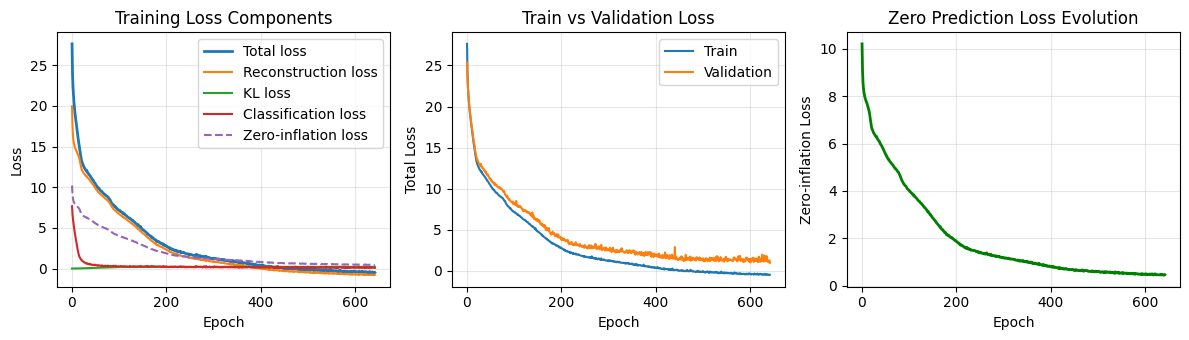

In [13]:
# Visualise training curves.
from utils.Sig_ZIB_VAE_utils import plot_model_training_curves_zib

plot_model_training_curves_zib(model)

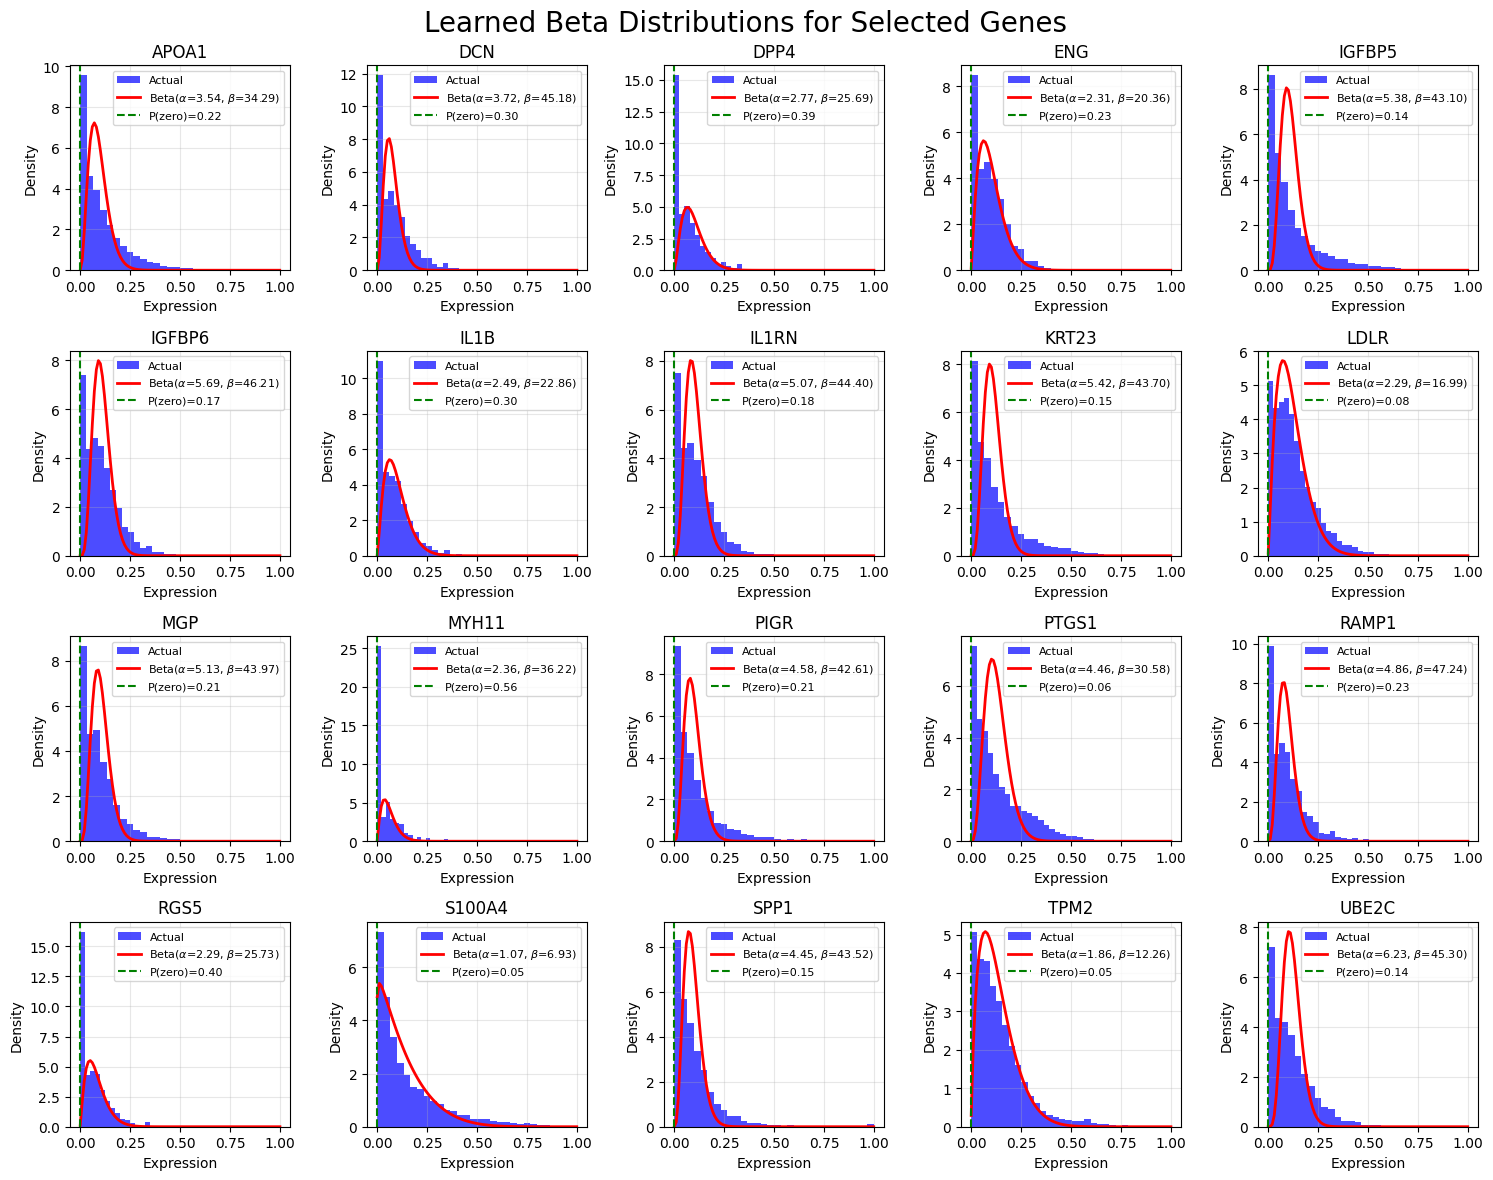

In [14]:
# Visualise learned Beta distribution parameters, relative to the actual expression data.
from utils.Sig_ZIB_VAE_utils import visualise_beta_parameters

visualise_beta_parameters(model, X_train, gene_names = gene_names)

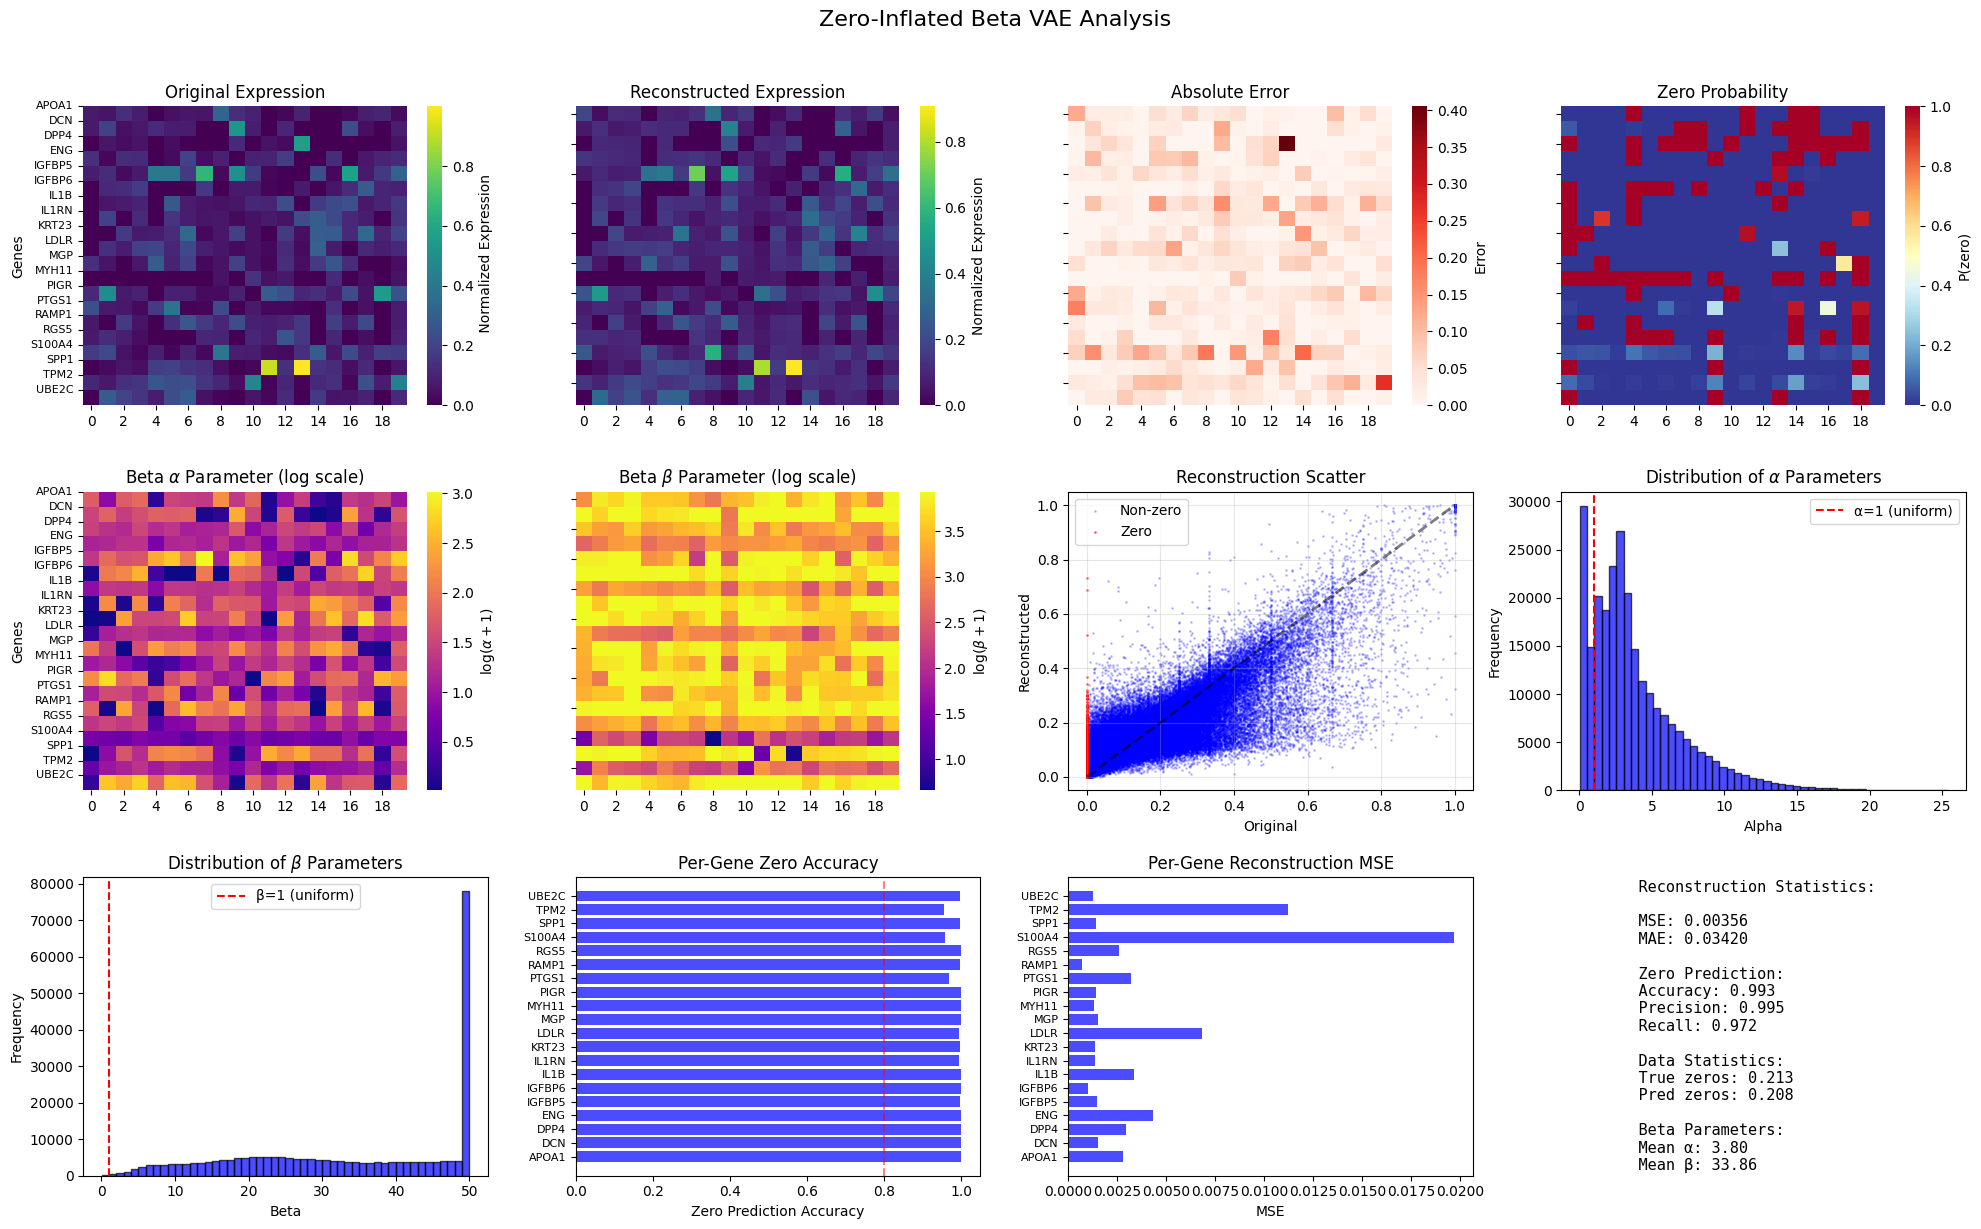

In [15]:
# Investigate reconstruction performance
from utils.Sig_ZIB_VAE_utils import analyze_zib_reconstruction

fig, metrics = analyze_zib_reconstruction(model, X_train, gene_names)

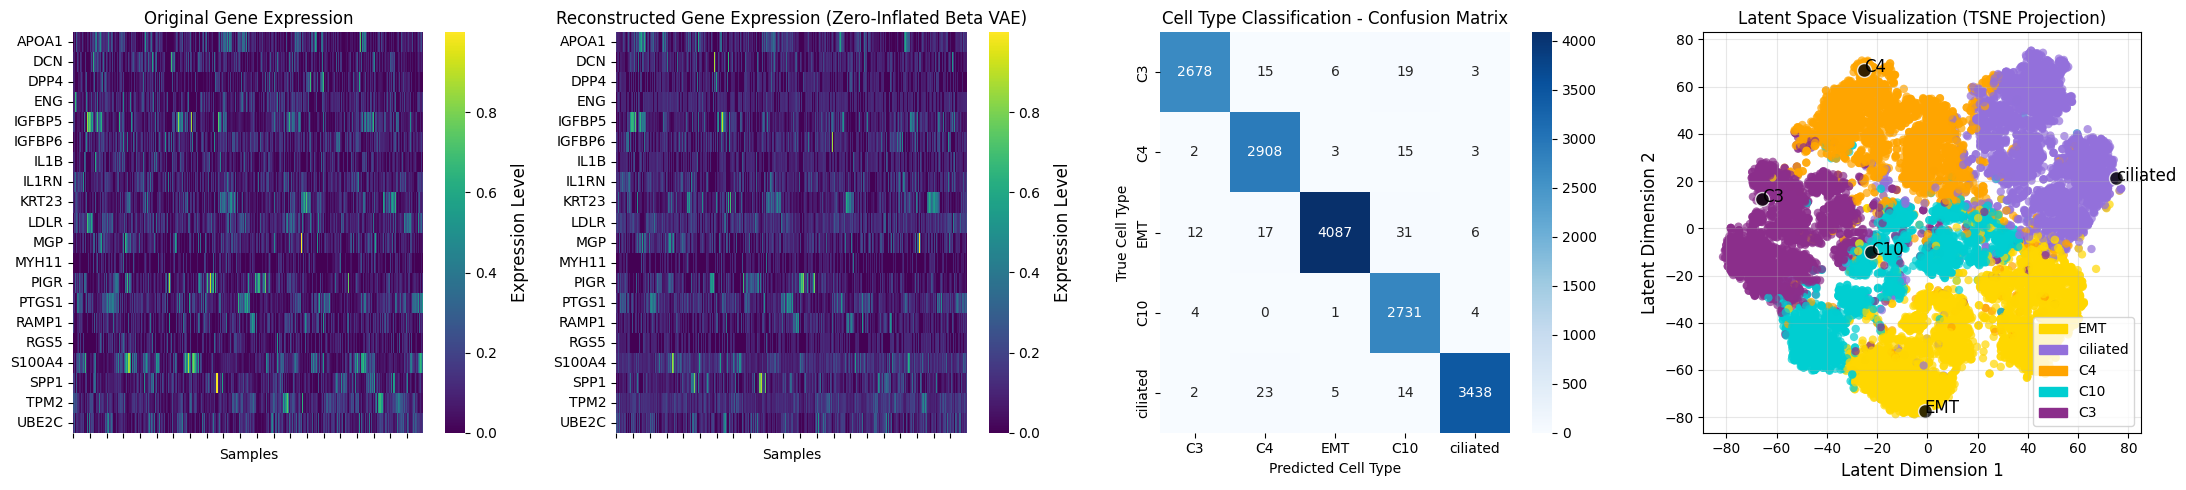

In [16]:
# Finally, visualise reconstruction on the full expression dataset + investigate classification performance and latent space clustering.
from utils.Sig_ZIB_VAE_utils import visualise_latent_space_and_reconstruction

projection =visualise_latent_space_and_reconstruction(model,
                                          expression_tensor,
                                          signature_tensor,
                                          gene_names = gene_names,
                                          projection = "tsne",
                                          latent_plot_kws={
                                              "legend_loc" : "lower right",
                                              "title_fontsize": 12
                                          },
                                          return_projection = True
                                          )

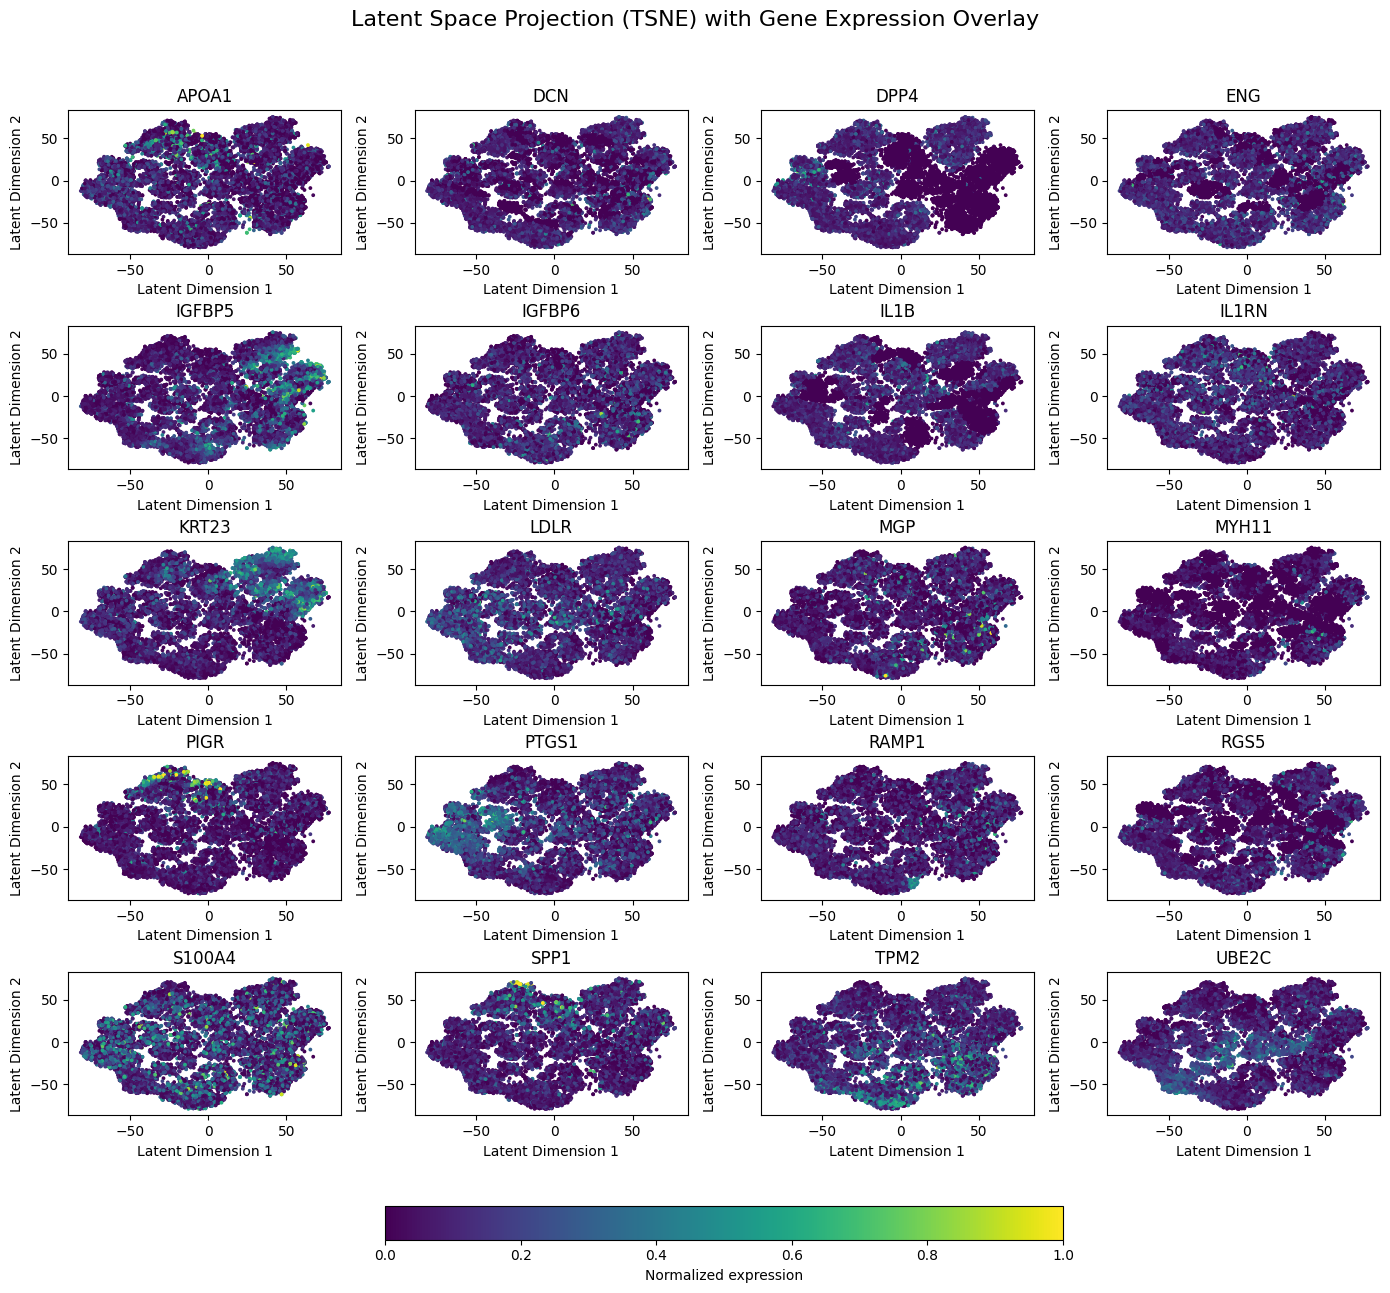

In [17]:
# Overlay the gene expression data over the recontruction
plt.figure(figsize=(14, 14))
fig = plt.gcf()

# Use a shared normalization for all subplots
vmin = 0.0
vmax = 1.0

for gene_idx, gene in enumerate(gene_names):
    ax = plt.subplot(5, 4, gene_idx + 1)
    # plot the projection and color by gene expression
    sc = ax.scatter(
        projection[:, 0],
        projection[:, 1],
        c=expression_tensor[:, gene_idx],
        cmap="viridis",
        s=3,
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_xlabel("Latent Dimension 1")
    ax.set_ylabel("Latent Dimension 2")
    ax.set_title(gene)

plt.suptitle("Latent Space Projection (TSNE) with Gene Expression Overlay", fontsize=16)
# plt.tight_layout()

# Reserve space for the bottom colorbar (and top title)
plt.tight_layout(rect=[0, 0.06, 1, 0.96])

# Create a single horizontal colorbar spanning all axes
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
sm = ScalarMappable(cmap="viridis", norm=Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])

cbar = fig.colorbar(sm, ax=fig.axes, orientation="horizontal", fraction=0.03, pad=0.08)
cbar.set_label("Normalized expression")

In [18]:
aggregated_malignant_df

,Patient_ID,Frame,Grid_X_Y,No_cells,Cell_names,APOA1,DCN,DPP4,ENG,IGFBP5,...,MGP_raw,MYH11_raw,PIGR_raw,PTGS1_raw,RAMP1_raw,RGS5_raw,S100A4_raw,SPP1_raw,TPM2_raw,UBE2C_raw
0,HGSC1,F001,0_0,19,"SMI_T10_F001_c7207,SMI_T10_F001_c7287,SMI_T10_...",1.573922,2.668908,0.934569,2.999990,1.109909,...,4.0,0.0,0.0,2.0,1.0,1.0,5.0,1.0,20.0,8.0
1,HGSC1,F001,0_1,14,"SMI_T10_F001_c6601,SMI_T10_F001_c6744,SMI_T10_...",0.589779,1.999994,0.999998,1.535002,0.635354,...,1.0,0.0,1.0,6.0,1.0,1.0,6.0,2.0,12.0,7.0
2,HGSC1,F001,0_2,19,"SMI_T10_F001_c6459,SMI_T10_F001_c6106,SMI_T10_...",1.837428,1.999994,0.999998,0.000000,0.870693,...,4.0,0.0,2.0,1.0,2.0,2.0,3.0,4.0,18.0,5.0
3,HGSC1,F001,0_3,25,"SMI_T10_F001_c5654,SMI_T10_F001_c5766,SMI_T10_...",3.707808,0.000000,1.977611,0.000000,0.000000,...,2.0,0.0,1.0,6.0,2.0,4.0,4.0,1.0,13.0,10.0
4,HGSC1,F001,0_4,23,"SMI_T10_F001_c5346,SMI_T10_F001_c5170,SMI_T10_...",1.729487,0.963116,1.999996,0.000000,1.401605,...,0.0,0.0,1.0,5.0,1.0,1.0,4.0,3.0,8.0,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16022,HGSC89,F020,20_8,17,"SMI_T14_F020_c2435,SMI_T14_F020_c2111,SMI_T14_...",1.384716,3.651953,0.000000,2.725204,1.398854,...,1.0,0.0,3.0,33.0,2.0,2.0,60.0,8.0,2.0,5.0
16023,HGSC89,F020,20_9,15,"SMI_T14_F020_c1802,SMI_T14_F020_c1848,SMI_T14_...",2.720851,0.000000,0.000000,1.999994,0.320030,...,2.0,1.0,0.0,28.0,1.0,0.0,37.0,3.0,5.0,6.0
16024,HGSC89,F020,20_10,19,"SMI_T14_F020_c1271,SMI_T14_F020_c1327,SMI_T14_...",1.630751,0.999997,0.999998,3.534991,1.049624,...,1.0,0.0,2.0,25.0,1.0,0.0,47.0,4.0,3.0,2.0
16025,HGSC89,F020,20_11,15,"SMI_T14_F020_c1004,SMI_T14_F020_c1118,SMI_T14_...",1.305996,0.000000,0.000000,2.999988,1.828279,...,1.0,0.0,0.0,12.0,1.0,0.0,25.0,2.0,5.0,1.0


In [ ]:
# with the entire dataset, compute proportions for each individual - this will be required for downstream analysis.
from utils.Sig_ZIB_VAE_utils import compute_cell_proportions

np.random.seed(73)
torch.manual_seed(73)
    
proportions = compute_cell_proportions(model,
                                       expression_tensor,
                                       aggregated_malignant_df,
                                       plotting=True,
                                       export=False) # set export to False to avoid overwriting

In [40]:
proportions_per_patient = proportions["per_patient"]
proportions_per_patient_fov = proportions["per_patient_fov"]

In [ ]:
# Save cell proportions DataFrame to csv
# proportions_per_patient.to_csv("data_processed/deconvolution_cell_proportions_per_patient.csv")
# proportions_per_patient_fov.to_csv("data_processed/deconvolution_cell_proportions_per_patient_fov.csv")

## Generating new samples.
_____

Generating samples for signature C3...
Generating samples for signature C4...
Generating samples for signature EMT...
Generating samples for signature C10...
Generating samples for signature ciliated...


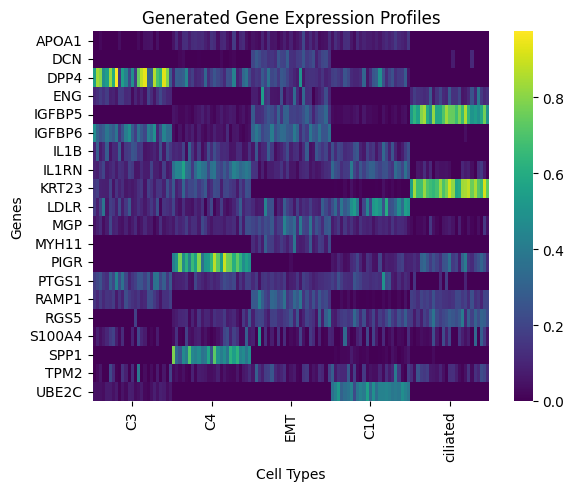

In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Beta
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from models.Sig_ZIB_VAE import generate_samples_from_signatures

generated_data = generate_samples_from_signatures(model,
                                     n_samples_per_type = 25,
                                     signature_names = None,
                                     sample_from_distribution = True)

all_generated_samples = []
for sig_name in generated_data.keys():  
    all_generated_samples.append(generated_data[sig_name]["samples"])
all_generated_samples = np.concatenate(all_generated_samples, axis=0)


sns.heatmap(all_generated_samples.T, cmap="viridis", yticklabels=gene_names,)
# add cell labels (25 samples for each signature), so we need 5 ticks on the x-axis, ho
plt.xticks(ticks=np.arange(0, 125, 25) + 12.5, labels=list(generated_data.keys()), rotation = 90)
plt.xlabel("Cell Types")
plt.ylabel("Genes")
plt.title("Generated Gene Expression Profiles")
plt.show()

# Train with the full dataset.
_____

Optionally, we can also resume training with the full dataset. However, this might lead to overfitting, and it is recommended to use the above best model.

NOTE: In the downstream analysis, the above model with seed = 73 was used. 

In [ ]:
from collections import OrderedDict
from models.Sig_ZIB_VAE import train_zib_model


full_model = Sig_ZIB_VAE(
    signature_tensor=signature_tensor,
    encoder_dim_list=config.encoder_dim_list,
    decoder_dim_list=config.decoder_dim_list,
    latent_dim=config.latent_dim,
    activation=config.activation,
    min_beta_param=0.01,
    max_beta_param=50.0)

seed = 73
arch_str = "_".join(map(str, config.encoder_dim_list))
best_model_path = checkpoint_root + f"/{arch_str}_latent_{latent_dim}/seed_{seed}/best_model.pt"

# load the best model.
ckpt = torch.load(best_model_path, map_location="cpu")
full_model.load_state_dict(ckpt["model_state_dict"])

optimizer = torch.optim.AdamW(full_model.parameters(), lr=config.learning_rate, weight_decay=config.weight_decay, betas = (0.9, 0.999))

# Compute the dataloaders again...
correlation = pytorch_pearson_corr(expression_tensor, signature_tensor)
correlation_probs = F.softmax(correlation, dim = 1)

cell_labels = torch.argmax(correlation_probs, dim = 1)

full_dataset = TensorDataset(expression_tensor, cell_labels)
full_dataloader = DataLoader(full_dataset, batch_size = 256, shuffle = True, drop_last = True)


train_zib_model(
		full_model,
		full_dataloader,
		optimizer,
		num_epochs=800,
		val_dataloader=None,
		kl_weight=config.kl_weight,
		class_weight=config.class_weight,
		zero_weight=config.zero_weight,
		kl_warmup_epochs=config.kl_warmup_epochs,
		checkpoint_dir="ZIB_VAE_final",
		checkpoint_freq=50,
		resume_from=best_model_path,
	)

Resuming training from epoch 642
Epoch: 650/800, Train Loss: -0.2877 (R:-0.656, KL:0.207, C:0.161, Z:0.519)
Epoch: 660/800, Train Loss: -0.3093 (R:-0.671, KL:0.205, C:0.157, Z:0.514)
Epoch: 670/800, Train Loss: -0.3933 (R:-0.738, KL:0.205, C:0.140, Z:0.483)
Epoch: 680/800, Train Loss: -0.3977 (R:-0.743, KL:0.204, C:0.141, Z:0.484)
Epoch: 690/800, Train Loss: -0.4801 (R:-0.778, KL:0.204, C:0.094, Z:0.467)
Epoch: 700/800, Train Loss: -0.4661 (R:-0.771, KL:0.205, C:0.101, Z:0.475)
Epoch: 710/800, Train Loss: -0.4792 (R:-0.797, KL:0.203, C:0.115, Z:0.462)
Epoch: 720/800, Train Loss: -0.5416 (R:-0.853, KL:0.203, C:0.108, Z:0.439)
Epoch: 730/800, Train Loss: -0.4913 (R:-0.793, KL:0.204, C:0.098, Z:0.461)
Epoch: 740/800, Train Loss: -0.5286 (R:-0.854, KL:0.203, C:0.123, Z:0.435)
Epoch: 750/800, Train Loss: -0.5852 (R:-0.867, KL:0.203, C:0.078, Z:0.432)
Epoch: 760/800, Train Loss: -0.5893 (R:-0.924, KL:0.203, C:0.132, Z:0.410)
Epoch: 770/800, Train Loss: -0.6100 (R:-0.908, KL:0.202, C:0.096, Z

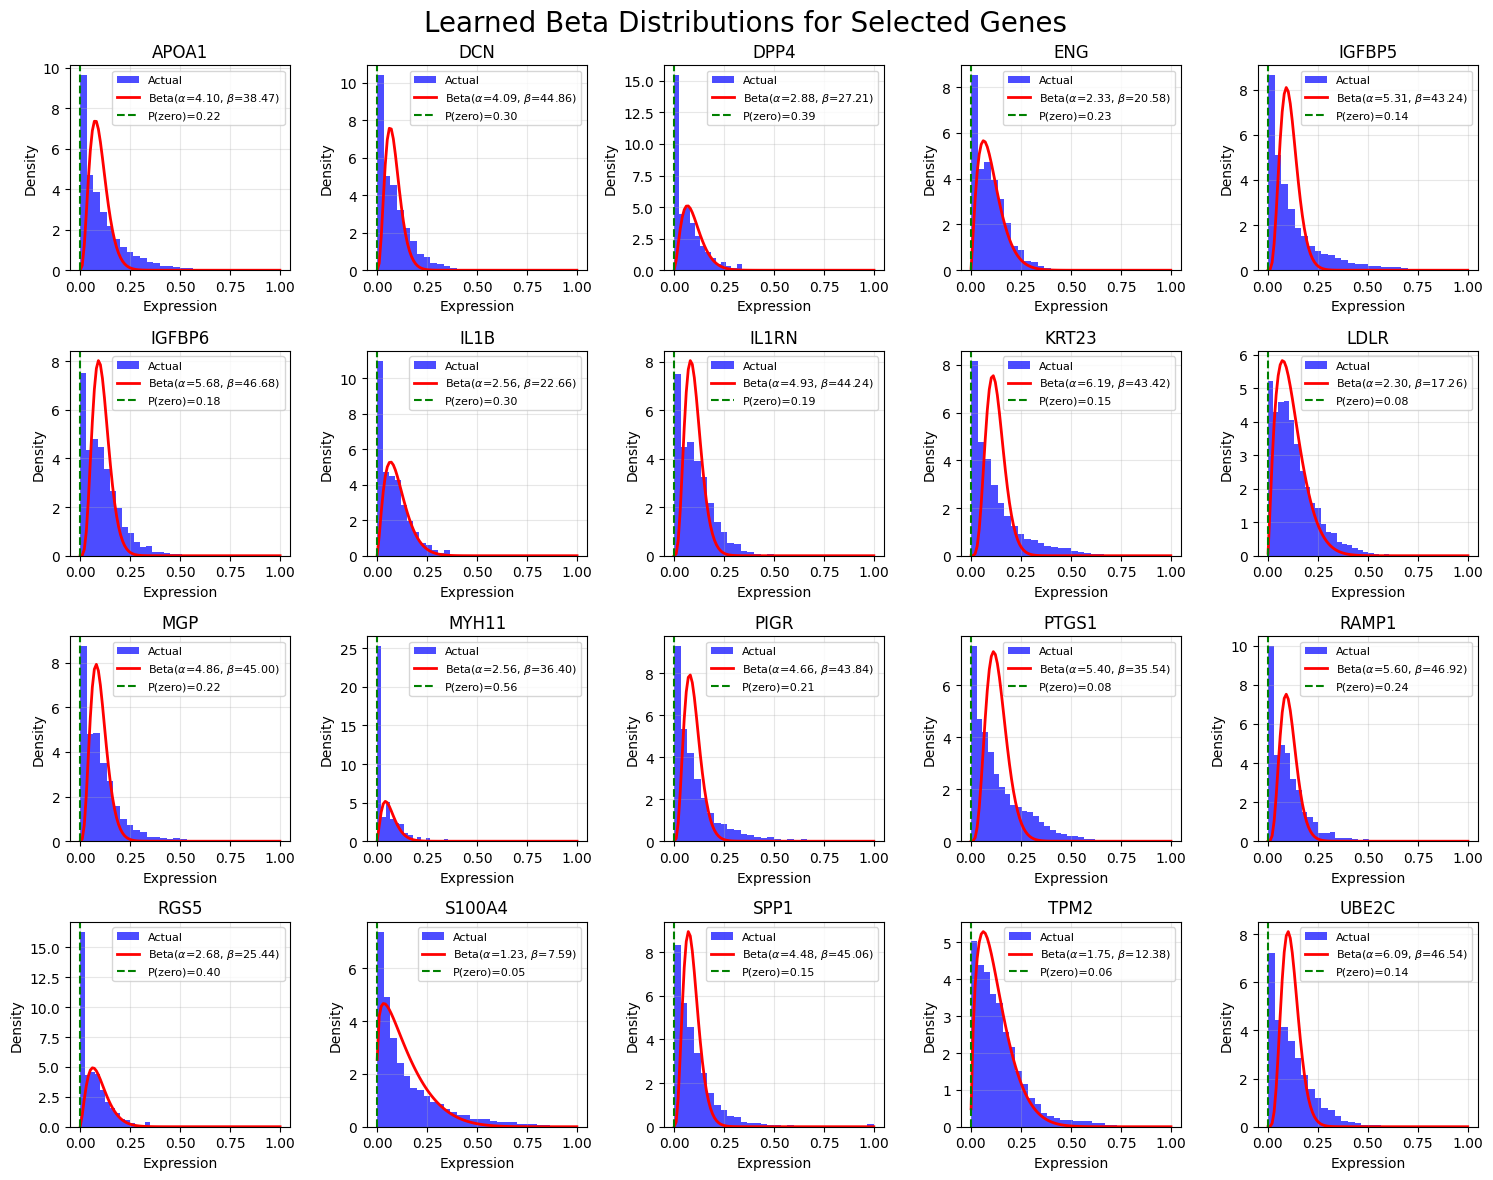

In [103]:
visualise_beta_parameters(full_model, expression_tensor, gene_names = gene_names)

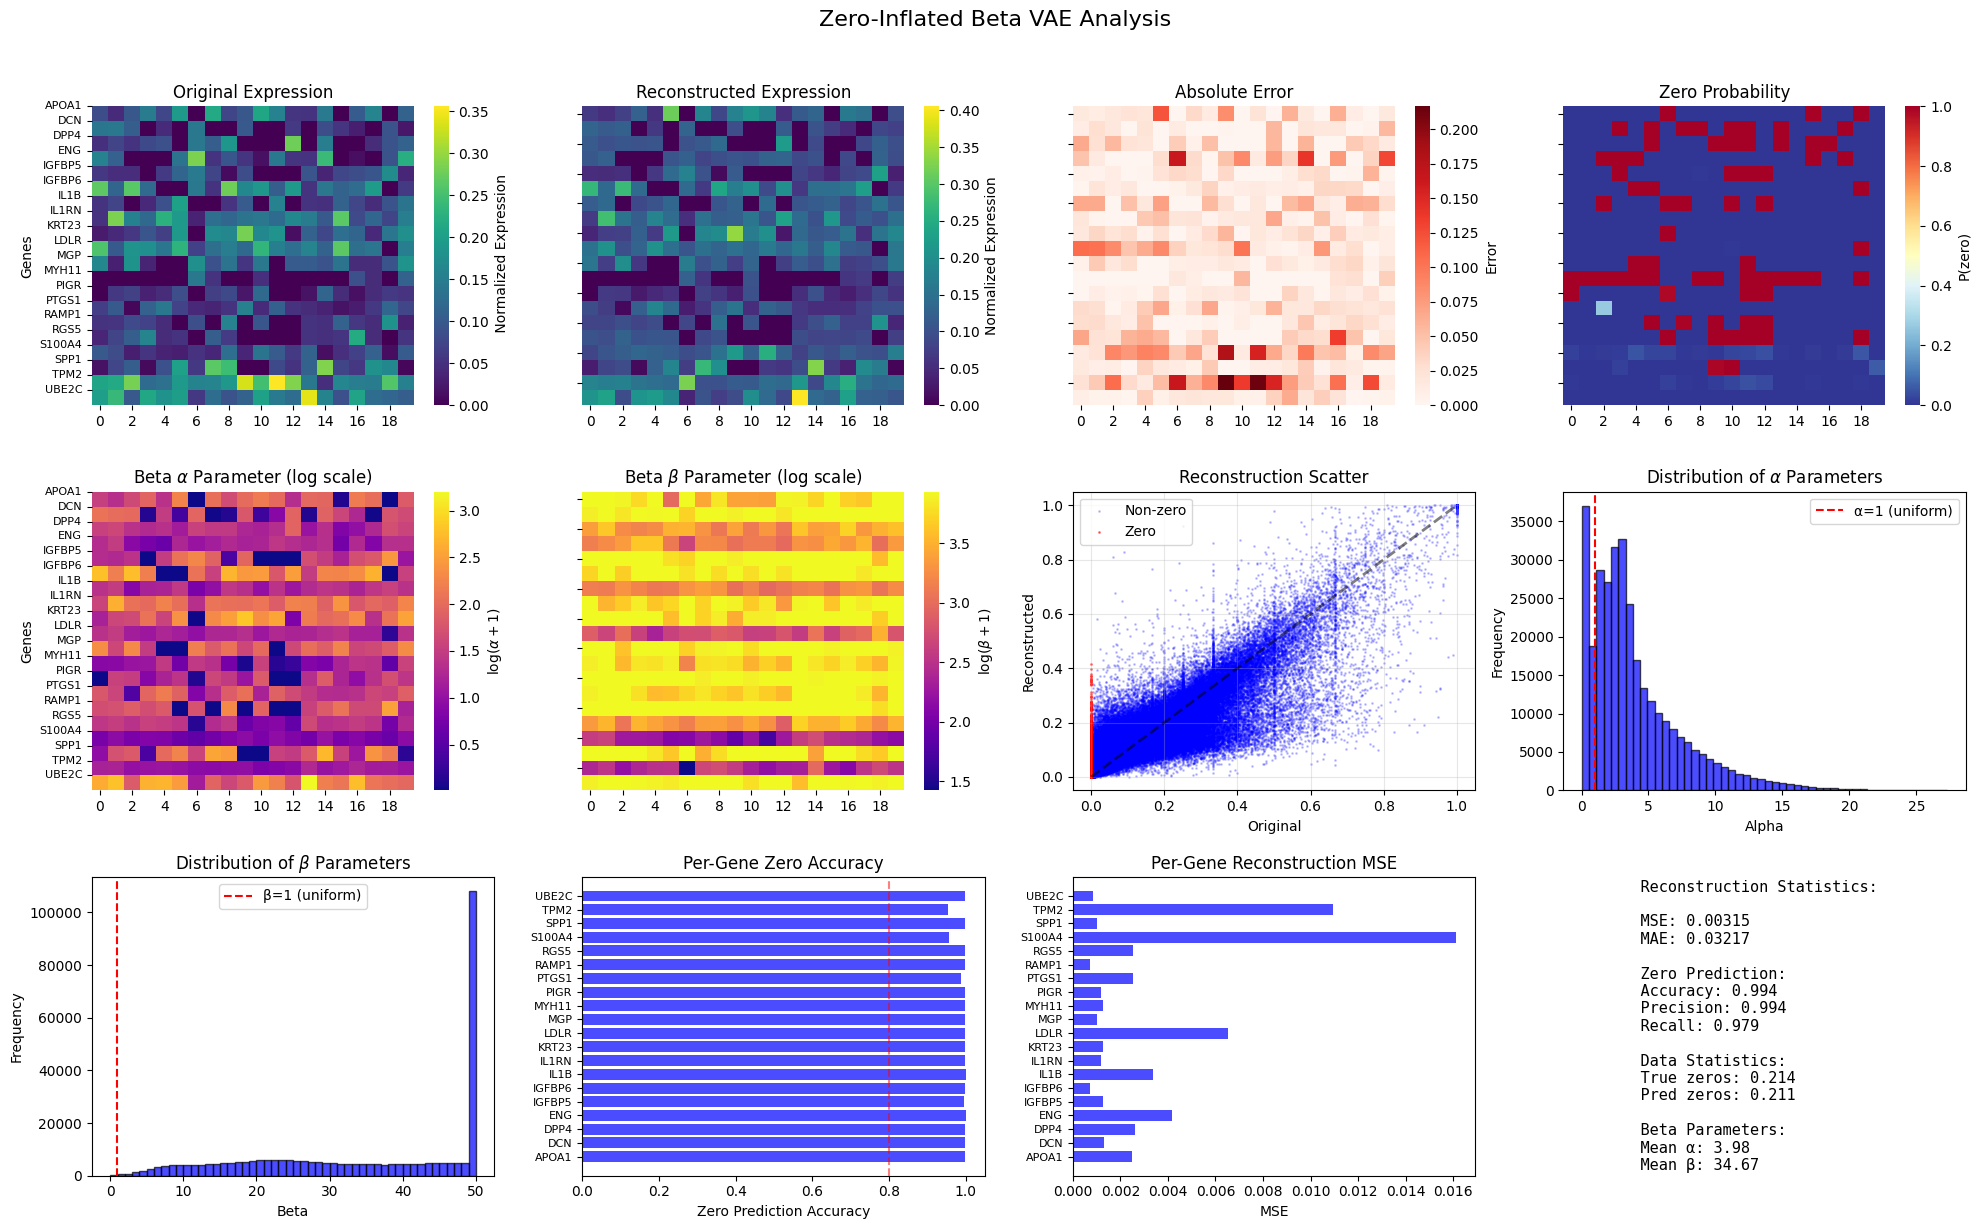

In [104]:
fig, metrics = analyze_zib_reconstruction(full_model, expression_tensor, gene_names)

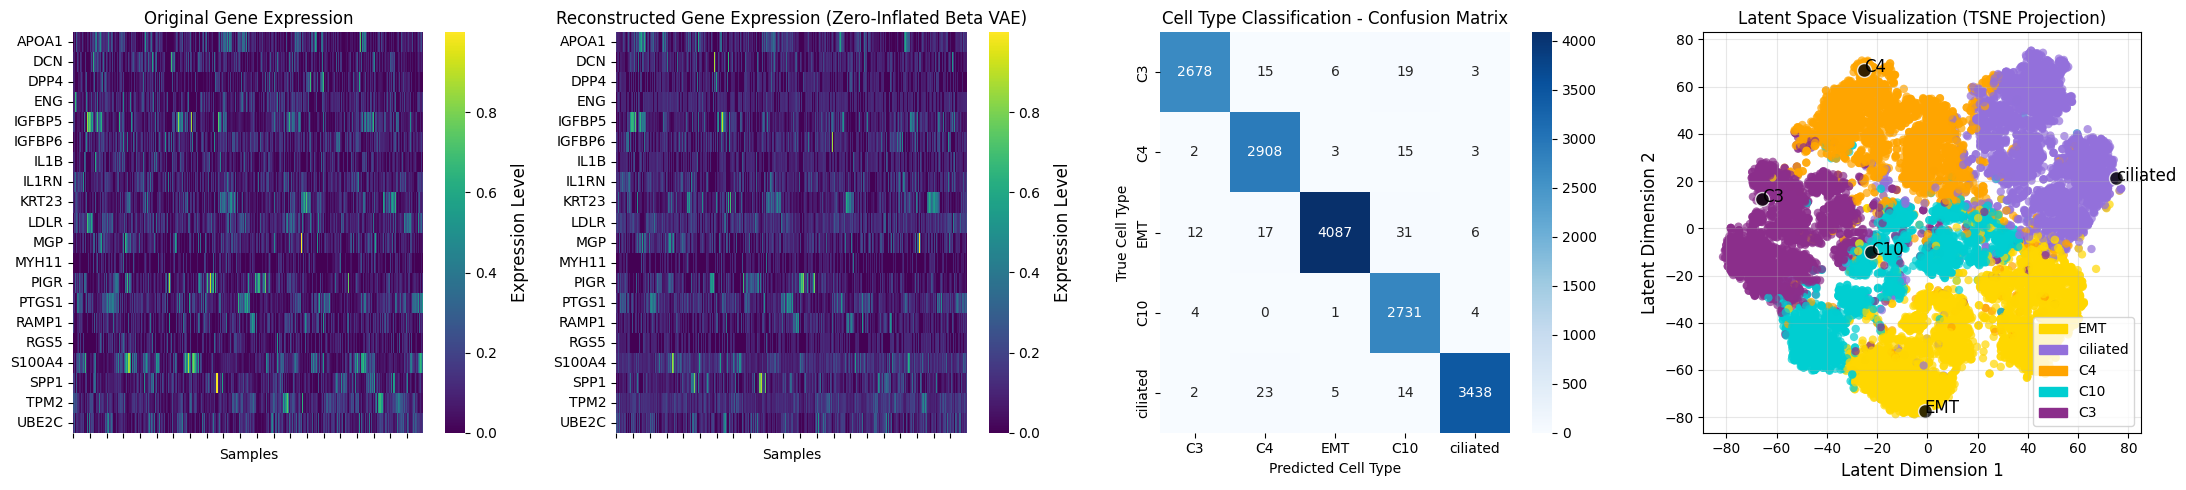

In [105]:
projection =visualise_latent_space_and_reconstruction(model,
                                          expression_tensor,
                                          signature_tensor,
                                          gene_names = gene_names,
                                          projection = "tsne",
                                          latent_plot_kws={
                                              "legend_loc" : "lower right",
                                              "title_fontsize": 12
                                          },
                                          return_projection = False
                                          )